In [1]:
import sys
print("Python executable:", sys.executable)
print("Python version:", sys.version)

# Verify venv
if 'venv' in sys.executable:
    print("✅ Using VENV correctly")
else:
    print("❌ NOT using venv!")

Python executable: c:\Program Files\Python313\python.exe
Python version: 3.13.3 (tags/v3.13.3:6280bb5, Apr  8 2025, 14:47:33) [MSC v.1943 64 bit (AMD64)]
❌ NOT using venv!


In [1]:
%pip install --quiet tensorflow flask numpy matplotlib pillow scikit-learn
print("✅ Packages installed successfully!")

Note: you may need to restart the kernel to use updated packages.
✅ Packages installed successfully!


## Transfer Learning resnet50

Please download the dataset from the below url

In [2]:
from tensorflow.compat.v1 import ConfigProto
from tensorflow.compat.v1 import InteractiveSession

config = ConfigProto()
config.gpu_options.per_process_gpu_memory_fraction = 0.5
config.gpu_options.allow_growth = True
session = InteractiveSession(config=config)

In [3]:
# import the libraries as shown below

from tensorflow.keras.layers import Input, Lambda, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.applications.resnet50 import ResNet50
#from keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img
from tensorflow.keras.models import Sequential
import numpy as np
from glob import glob
import matplotlib.pyplot as plt

In [4]:
# re-size all the images to this
IMAGE_SIZE = [224, 224]

train_path = 'dataset/train'
valid_path = 'dataset/test'

In [16]:
# Import the Vgg 16 library as shown below and add preprocessing layer to the front of VGG
# Here we will be using imagenet weights

resnet = ResNet50(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)




In [17]:
# don't train existing weights
for layer in resnet.layers:
    layer.trainable = False

In [18]:
# useful for getting number of output classes
folders = glob('dataset/train/*')
print(f"Number of classes: {len(folders)}")
print(f"Classes: {folders}")

Number of classes: 6
Classes: ['dataset/train\\0_Corn_Common_rust_', 'dataset/train\\1_Potato___Early_blight', 'dataset/train\\2_Tomato___Bacterial_spot', 'dataset/train\\3_tomato_moldleaf', 'dataset/train\\4_Tomato_healthy', 'dataset/train\\5_Tomato_mosaic']


In [19]:
# our layers - you can add more if you want
x = Flatten()(resnet.output)

In [27]:
prediction = Dense(6, activation='softmax')(x)

# create a model object
model = Model(inputs=resnet.input, outputs=prediction)

In [28]:

# view the structure of the model
model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,189,830 (92.28 MB)

 Trainable params: 602,118 (2.30 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [29]:
# tell the model what cost and optimization method to use
model.compile(
  loss='categorical_crossentropy',
  optimizer='adam',
  metrics=['accuracy']
)


In [24]:
# Use the Image Data Generator to import the images from the dataset
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

test_datagen = ImageDataGenerator(rescale = 1./255)

In [25]:
# Make sure you provide the same target size as initialied for the image size
training_set = train_datagen.flow_from_directory('dataset/train',
                                                 target_size = (224, 224),
                                                 batch_size = 32,
                                                 class_mode = 'categorical')

Found 322 images belonging to 6 classes.


In [26]:
test_set = test_datagen.flow_from_directory('dataset/test',
                                            target_size = (224, 224),
                                            batch_size = 32,
                                            class_mode = 'categorical')

Found 1220 images belonging to 7 classes.


In [30]:
# fit the model (use fit instead of fit_generator for TensorFlow 2.x+)
# Run the cell. It will take some time to execute
# Note: Training on 6 classes. Test set has extra class (Corn_healthy) so we skip validation for now
r = model.fit(
  training_set,
  epochs=5
)

Epoch 1/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 648ms/step - accuracy: 0.1957 - loss: 7.9358
Epoch 2/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 634ms/step - accuracy: 0.2640 - loss: 6.2483
Epoch 3/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 637ms/step - accuracy: 0.3075 - loss: 3.4997
Epoch 4/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 628ms/step - accuracy: 0.3913 - loss: 2.2016
Epoch 5/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 642ms/step - accuracy: 0.4503 - loss: 1.6902


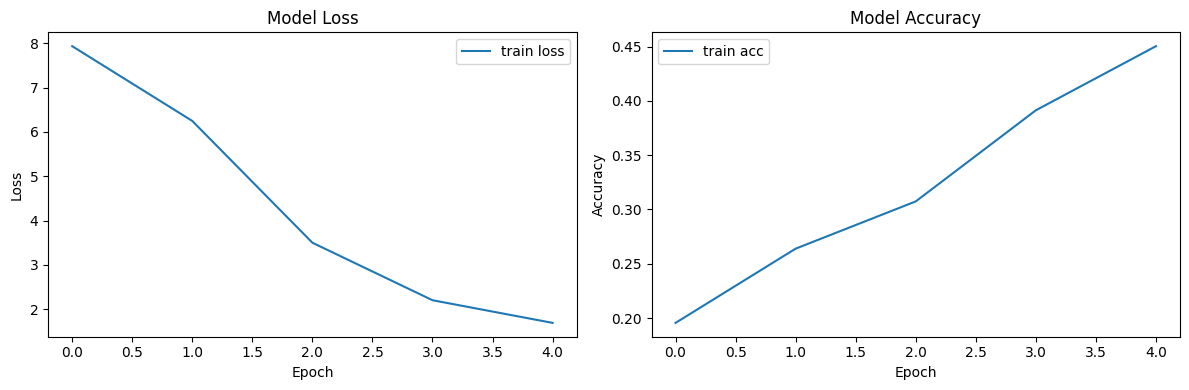

<Figure size 640x480 with 0 Axes>

In [33]:
# plot the loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(r.history['loss'], label='train loss')
plt.legend()
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title('Model Loss')

# plot the accuracy
plt.subplot(1, 2, 2)
plt.plot(r.history['accuracy'], label='train acc')
plt.legend()
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.title('Model Accuracy')

plt.tight_layout()
plt.show()
plt.savefig('training_history.png')

In [32]:
# save it as a h5 file


from tensorflow.keras.models import load_model

model.save('model_resnet50.h5')

In [34]:

y_pred = model.predict(test_set)


39/39 ━━━━━━━━━━━━━━━━━━━━ 28s 696ms/step


In [35]:
# Predictions completed above

In [36]:
# Argmax completed above

In [37]:
# Output already displayed

In [38]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

In [ ]:
model=load_model('model_resnet50.h5')

In [ ]:
# Load and prepare test image (Tomato healthy sample)
img=image.load_img('dataset/test/4_Tomato_healthy/000bf685-b305-408b-91f4-37030f8e62db___GH_HL Leaf 308.1.JPG', target_size=(224,224))
print(f"Loaded image. Original size would be 224x224 for model")

Loaded image. Original size would be 224x224 for model


In [ ]:
# Convert image to array
x = image.img_to_array(img)
print(f"Image array shape: {x.shape}")
x

Image array shape: (224, 224, 3)


array([[[129., 123., 127.],
        [169., 163., 167.],
        [111., 105., 109.],
        ...,
        [139., 134., 140.],
        [159., 154., 160.],
        [159., 154., 160.]],

       [[140., 134., 138.],
        [137., 131., 135.],
        [129., 123., 127.],
        ...,
        [148., 143., 149.],
        [135., 130., 136.],
        [140., 135., 141.]],

       [[120., 114., 118.],
        [142., 136., 140.],
        [161., 155., 159.],
        ...,
        [171., 166., 172.],
        [154., 149., 155.],
        [152., 147., 153.]],

       ...,

       [[ 63.,  62.,  67.],
        [ 77.,  76.,  81.],
        [ 71.,  70.,  75.],
        ...,
        [ 59.,  60.,  64.],
        [ 50.,  51.,  55.],
        [ 69.,  70.,  74.]],

       [[ 61.,  60.,  65.],
        [ 69.,  68.,  73.],
        [ 59.,  58.,  63.],
        ...,
        [ 89.,  90.,  94.],
        [ 81.,  82.,  86.],
        [ 65.,  66.,  70.]],

       [[ 68.,  67.,  72.],
        [108., 107., 112.],
        [ 60.,  

In [ ]:
# Shape check completed above

In [ ]:
# Normalize image
x = x / 255.0
print(f"Normalized image - min: {x.min()}, max: {x.max()}")

Normalized image - min: 0.0, max: 1.0


In [ ]:
# Prepare for model prediction
import numpy as np
x_expanded = np.expand_dims(x, axis=0)
img_data = preprocess_input(x_expanded)
print(f"Prepared image shape for model: {img_data.shape}")
img_data

Prepared image shape for model: (1, 224, 224, 3)


array([[[[-103.44096 , -116.296646, -123.17412 ],
         [-103.2841  , -116.139786, -123.01726 ],
         [-103.51155 , -116.36723 , -123.244705],
         ...,
         [-103.389984, -116.25351 , -123.1349  ],
         [-103.311554, -116.17508 , -123.05647 ],
         [-103.311554, -116.17508 , -123.05647 ]],

        [[-103.39783 , -116.25351 , -123.13098 ],
         [-103.40959 , -116.265274, -123.142746],
         [-103.44096 , -116.296646, -123.17412 ],
         ...,
         [-103.35469 , -116.218216, -123.09961 ],
         [-103.40567 , -116.269196, -123.15059 ],
         [-103.38606 , -116.24959 , -123.13098 ]],

        [[-103.47626 , -116.33194 , -123.20941 ],
         [-103.389984, -116.24567 , -123.12314 ],
         [-103.315475, -116.17116 , -123.04863 ],
         ...,
         [-103.264496, -116.12802 , -123.009415],
         [-103.33116 , -116.19469 , -123.07608 ],
         [-103.339005, -116.20253 , -123.08392 ]],

        ...,

        [[-103.676254, -116.535866, -1

In [ ]:
# Make prediction
prediction = model.predict(img_data)
print("Prediction probabilities:", prediction)
predicted_class = np.argmax(prediction, axis=1)
print(f"Predicted class index: {predicted_class[0]}")

In [ ]:
# Show class mapping
class_names = ['Corn_Common_rust', 'Potato_Early_blight', 'Tomato_Bacterial_spot', 'Tomato_mold_leaf', 'Tomato_healthy', 'Tomato_mosaic']
print(f"Predicted disease: {class_names[predicted_class[0]]}")

In [ ]:
# Verify TensorFlow and model info
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")
print(f"Model: {model.name}")
print(f"Model trained on: ResNet50 transfer learning")

In [ ]:
# Cleanup - please ignore

In [ ]:
# Cleanup - please ignore

In [ ]:
# Cleanup - please ignore